## Libraries

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn import clone
from sklearn.feature_selection import RFE
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, median_absolute_error, r2_score, root_mean_squared_error, root_mean_squared_log_error
from sklearn.model_selection import ParameterGrid


## Import

In [2]:
X = pd.read_csv('../new_datasets/X_trainval_preprocessed.csv')
y = pd.read_csv('../new_datasets/y_trainval.csv').values.ravel()

C:\Users\rafad\AppData\Local\Temp\ipykernel_25240\1709477896.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  X = pd.read_csv('../new_datasets/X_trainval_preprocessed.csv')


In [3]:
X.head()

,Brand,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage,mileage_per_year,tax_engineSize,age_mileage,mpg_engineSize,miles_mpg,age
0,VW,Semi-Auto,28421.0,Petrol,120-240,11.417268,2.0,4.000000,0.0,3157.888889,NaN,255789.0,22.834536,324490.166831,9.0
1,Toyota,Manual,4589.0,Petrol,120-240,47.900000,1.5,1.000000,0.0,764.833333,217.5,27534.0,71.850000,219813.100000,6.0
2,Audi,Semi-Auto,3624.0,Petrol,120-240,40.900000,1.5,4.000000,0.0,604.000000,217.5,21744.0,61.350000,148221.600000,6.0
3,Ford,Manual,9102.0,Petrol,120-240,65.700000,1.0,2.340306,0.0,1300.285714,145.0,63714.0,65.700000,598001.400000,7.0
4,BMW,Manual,1000.0,Petrol,120-240,42.800000,1.5,3.000000,0.0,166.666667,217.5,6000.0,64.200000,42800.000000,6.0


In [104]:
X.shape

(74124, 15)

In [105]:
y

array([22290, 13790, 24990, ...,  8399, 12990, 10495])

## Functions

In [3]:
def select_rfe(X, y, names, n_features=15):

    '''
    Selects the most revelant features using RFE with Ridge algorithm (wrapper method)

    The function fits an RFE selector on the data and returns the names of the selected features

    Args:
        X (pandas.DataFrame): Features of the training data
        y (array): Targets of X
        names (list or str): List containing the features in X (same order)
        n_features (int): Number of features to select (50 by default), In case of X having less features than the value, all available features are considered

    Returns
        selected_features (list): List with the names of the features selected by the RFE
    
    '''
    #In case our data has less than n_features (50 by default) we adjust the number of features
    n_features = min(n_features, X.shape[1])
    
    rfe = RFE(estimator=Ridge(alpha=1.0), n_features_to_select=n_features, step=1)
    rfe.fit(X, y)
    
    # PROTEÇÃO CRÍTICA: Iteramos apenas até ao limite seguro
    limit = min(len(names), len(rfe.support_))
    
    return [names[i] for i in range(limit) if rfe.support_[i]]

In [51]:
def select_ridge(X, y, names, alpha=5):

    """
    Selects relevant features based on Ridge regression coefficients (L2 regularization).

    The function fits a Ridge regression model and returns the names of
    features whose absolute coefficients are above a small threshold (since the coefficients never get to 0).


    Args:
    
        X (pandas.DataFrame): Feature of the training data

        y (array): Target of X.

        names (list or str): List containing the features in X (same order)

        alpha (float): Regularization strength for Ridge regression. Higher values increase coefficient shrinkage.

    Returns
        selected_features (list of str): Names of features whose absolute (Ridge) coefficient is greater than 1e-5.
        
    """

    ridge = Ridge(alpha=alpha)
    ridge.fit(X, y)
    
    # PROTEÇÃO CRÍTICA: O limite é o menor entre nomes e coeficientes
    limit = min(len(names), len(ridge.coef_))
    
    return [names[i] for i in range(limit) if abs(ridge.coef_[i]) > 1e-3]

In [58]:
def select_lasso(X, y, names, alpha=5):

    """
    Selects relevant features using Lasso regression coefficients (L1 regularization).

    The function fits a Lasso regression model and returns the names of
    features whose coefficients are non-zero.

    Args:
    
        X (pandas.DataFrame): Feature of the training data

        y (array): Target of X.

        names (list or str): List containing the features in X (same order)

        alpha (float): Regularization strength for Lasso regression. Higher value increase sparsity and result in fewer selected features

    Returns
    
        selected_features (list of str): Names of features with non-zero Lasso coefficients.
        
    """

    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    
    # PROTEÇÃO CRÍTICA
    limit = min(len(names), len(lasso.coef_))
    
    return [names[i] for i in range(limit) if lasso.coef_[i] != 0]

In [59]:
def consensus_features(X, y, names, min_votes=2, rfe_n_features=None):
    """
    Feature selection via:
    1) Lasso + Ridge voting to define a candidate pool
    2) RFE (with Ridge) applied only to that pool

    Args:
        X (ndarray): Scaled training features
        y (array): Training target
        names (list of str): Feature names (aligned with X)
        min_votes (int): Minimum votes from Lasso + Ridge to enter the pool
        rfe_n_features (int or None): Final number of features selected by RFE.
                                      If None, keeps all pooled features.
        ridge_alpha (float): Ridge alpha
        lasso_alpha (float): Lasso alpha

    Returns:
        selected_features (list of str)
    """

    # --- 1) Free voting phase (no cardinality constraints) ---
    f_lasso = select_lasso(X, y, names)
    f_ridge = select_ridge(X, y, names)

    votes = Counter(f_lasso + f_ridge)

    pool = [feat for feat, count in votes.items() if count >= min_votes]

    # Safety net: if pool collapses, fall back to union
    if len(pool) == 0:
        pool = sorted(set(f_lasso) | set(f_ridge))

    # --- 2) RFE refinement phase ---
    if rfe_n_features is None or rfe_n_features >= len(pool):
        return sorted(pool)

    # Reduce X to pooled features
    pool_idx = [names.index(f) for f in pool]
    X_pool = X[:, pool_idx]

    refined = select_rfe(
        X_pool,
        y,
        pool,
        n_features=rfe_n_features
    )

    return sorted(refined)

In [7]:
def best_model_per_metric(metrics_df):
    best = {}

    best["R2"] = metrics_df["R2"].idxmax()
    best["MAE"] = metrics_df["MAE"].idxmin()
    best["MSE"] = metrics_df["MSE"].idxmin()
    best["MAPE"] = metrics_df["MAPE"].idxmin()
    best["MedAE"] = metrics_df["MedAE"].idxmin()

    return best

In [21]:
def plot_comparison(full_results, metric_name='MedAE'):
    # Preparar dados para o formato "long" que o seaborn gosta
    plot_data = full_results[[f"Train_{metric_name}", f"Val_{metric_name}"]].reset_index()
    plot_data = plot_data.melt(id_vars='index', var_name='Dataset', value_name='Metric')
    plot_data['Dataset'] = plot_data['Dataset'].str.replace(f'_{metric_name}', '')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_data, x='index', y='Metric', hue='Dataset', palette='viridis')
    
    plt.title(f'Diference of {metric_name} per Model', fontsize=15)
    plt.xlabel('Model')
    plt.ylabel(metric_name)
    plt.xticks(rotation=45)
    plt.legend(title='Dataset')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

## Models

To identify the model that best fits our data, several regression algorithms with different biases were trained and validated. This comparative approach allows us to evaluate both linear and non-linear relationships, as well as parametric and ensemble-based methods.

The following seven models were considered:
- Linear Regression
- Ridge Regression
- Random Forest
- Decision Tree
- Gradient Boosting
- MLP (Multi-layer Perceptron)
- LinearSVM (Support Vector Machine): since SVM doesn't scale well for datasets with more than 10k rows

In [53]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1),
    'Random Forest': RandomForestRegressor(n_estimators= 100, random_state=42, max_depth = 20, n_jobs=-1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300,learning_rate=0.1,max_depth=5,random_state=42),
    'Neural Network (MLP)': MLPRegressor(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

## Metrics

To be able to compare the performance of the trained models, 5 evaluation metrics were used. Each metric capture either a degree of explainability of the model or the error on the predicted and observed values.

The following metrics were considered:
- **R²**: Measures the proportion of the variance for a dependent variable. Provides an indication of how well the data points fit a statistical model

- **MAE** (Mean Absolute Error): Computes the average absolute difference between predicted and actual values. (Tells by how much the model is missing)

- **MSE** (Mean Squared Error): Calculates the average of the squared prediction errors. By squaring the errors, this metric penalizes large mistakes more heavily than MAE.

- **MAPE** (Mean Absolute Percentage Error): Measures the average absolute error as a percentage of the true values. 

- **MedAE** (Median Absolute Error): Computes the median of the absolute prediction errors. 

Using multiple metrics avoids over-optimizing for a single criterion and helps reveal trade-offs between accuracy, robustness, and sensitivity to extreme errors.

In [9]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'MSE': mean_squared_error,
    'RMSE': root_mean_squared_error,
    #'RMSLR': root_mean_squared_log_error,
    'MAPE': mean_absolute_percentage_error,
    'MedAE': median_absolute_error
}

## Cross-Validation

To train the models we opted by the Cross-Validation strategy. This method compares the models by dividing the training data into 5. From those 5 datasets 1 will be the validation, that will be changed into a training dataset in the next interation, making every "mini" dataset be the validation dataset once.

In [10]:
#Using the Standard Cross-Validation to evaluate the model
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
results = {name: {m: [] for m in metrics} for name in models}

In [54]:
# Initialize dictionaries to store results
results_val = {name: {m: [] for m in metrics.keys()} for name in models.keys()}
results_train = {name: {m: [] for m in metrics.keys()} for name in models.keys()}

To ensure that the CV (Cross-Validation) doesn't leak any data, we need to make a few steps before spliting and going straith to training. We decided to divide this task into 5 steps:

#### Data Spliting

To start the CV, we create a loop that divides the dataset into training and validation. using this loop, we can guarantee that every mini dataset is used for validation once.

#### Preprocessing

All preprocessing steps are fitted exclusively on the training data and then applied to the validation data. This prevents data leakage and ensures a fair evaluation. In this step, we take care of:

- **Missing values** in numerical features are imputed using the median computed from the training fold.

- **Categorical features** are encoded using one-hot encoding.

- Unknown categories in the validation set are safely ignored.

After encoding, numerical and categorical features are concatenated into a single feature matrix.

#### Feature Scaling

All features are scaled using Min-Max normalization, fitted only on the training data and then applied to the validation data.

We need to do this step because we use scale-sensitive models such as Support Vector Machines (LinearSVR) and Neural Networks (MLP).

#### Feature Selection

Feature selection is performed inside each cross-validation fold, using only the training data.

A consensus-based feature selection strategy is applied, combining:

- Recursive Feature Elimination (RFE),

- Ridge regression coefficient filtering,

- Lasso regression sparsity.

Only features selected by a majority of these methods are retained. The same subset of features is then applied to both training and validation sets for that fold.

This approach favors stable and robust features while avoiding information leakage.

#### Model Training and Evaluation

Each model is trained on the selected features of the training fold and evaluated on the corresponding validation fold.

Predictions are assessed using the evaluation metrics already inicialized a few cells above

The results for each model and metric are stored across all folds, enabling later aggregation and comparison.

In [60]:
fold = 1
for train_index, val_index in cv.split(X,y):
    print(f"Processing Fold {fold}/5...")
# 1- Data Split
    X_train_fold = X.iloc[train_index].copy()
    X_val_fold = X.iloc[val_index].copy()

    y_train_fold = y[train_index]
    y_val_fold = y[val_index]
    
    # Log Transform of our target
    #y_train_log = np.log1p(y_train_fold)
# 2- Preprocessing
    # Seperation of the numeric columns
    numeric_cols = X_train_fold.select_dtypes(include=np.number).columns

    # Impute the null values
    imputer = SimpleImputer(strategy='median')
    imputer.fit(X_train_fold[numeric_cols])  

    # Apply the transformation
    X_train_fold[numeric_cols] = imputer.transform(X_train_fold[numeric_cols])
    X_val_fold[numeric_cols] = imputer.transform(X_val_fold[numeric_cols])

    #Encoding
    categorical_cols = X_train_fold.select_dtypes(include=['object', 'bool']).columns

    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    encoder.fit(X_train_fold[categorical_cols])

    X_train_encoded = encoder.transform(X_train_fold[categorical_cols])
    X_val_encoded = encoder.transform(X_val_fold[categorical_cols])

    X_train_final = np.hstack([X_train_fold[numeric_cols].values, X_train_encoded])
    X_val_final = np.hstack([X_val_fold[numeric_cols].values, X_val_encoded])

    encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
    all_feature_names = list(numeric_cols) + list(encoded_feature_names)

# 3- Scaling
    scaler = MinMaxScaler()
    scaler.fit(X_train_final) # Fit on TRAIN only
    
    X_train_scaled = scaler.transform(X_train_final)
    X_val_scaled = scaler.transform(X_val_final)


# 4 - Feature Selection
    # Calls the consensus function passing the column names
    selected = consensus_features(X_train_scaled, y_train_fold, all_feature_names)
    print(selected) #print selected features
    print(len(selected)) #print the number of selected features

    # Find the indexes of the selected columns
    sel_idx = [all_feature_names.index(f) for f in selected]

    # Final datasets 
    X_train_final = X_train_scaled[:, sel_idx]
    X_val_final   = X_val_scaled[:, sel_idx]
    
# 5 - Training and Evaluation
    for name, model in models.items():
        m = clone(model)
        m.fit(X_train_final, y_train_fold)
        
        # --- VALIDATION EVALUATION ---
        pred_val = m.predict(X_val_final)
        #pred_val = np.expm1(pred_log_val)
        
        # --- TRAINING EVALUATION ---
        pred_train = m.predict(X_train_final)
        #pred_train = np.expm1(pred_log_train)

        for m_name, func in metrics.items():
            # Store Validation Score
            v_score = func(y_val_fold, pred_val)
            results_val[name][m_name].append(v_score)
            
            # Store Training Score
            t_score = func(y_train_fold, pred_train)
            results_train[name][m_name].append(t_score)
            
    fold += 1



Processing Fold 1/5...


c:\Users\rafad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


['Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Opel', 'Brand_Skoda', 'Brand_Toyota', 'Brand_Unknown', 'Brand_VW', 'age', 'engineSize', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'fuelType_Unknown', 'mileage_per_year', 'miles_mpg', 'model_2 Series', 'model_3 Series', 'model_4 Series', 'model_5 Series', 'model_7 Series', 'model_8 Series', 'model_A Class', 'model_A1', 'model_A3', 'model_A4', 'model_A8', 'model_Adam', 'model_Auris', 'model_Aygo', 'model_B Class', 'model_B-MAX', 'model_C Class', 'model_C-MAX', 'model_CL Class', 'model_Caravelle', 'model_Citigo', 'model_Corsa', 'model_E Class', 'model_EcoSport', 'model_Edge', 'model_Fabia', 'model_Fiesta', 'model_Focus', 'model_G Class', 'model_GLA Class', 'model_GLC Class', 'model_GLE Class', 'model_GLS Class', 'model_Galaxy', 'model_Golf', 'model_Golf SV', 'model_Grandland X', 'model_IX20', 'model_Insignia', 'model_Ka', 'model_Karoq', 'model_Kodiaq', 'model_Land Cruiser', 'model_M4', 'model_Mokka X', 'model_Octavia', 'mod

c:\Users\rafad\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Processing Fold 2/5...


...

c:\Users\rafad\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Processing Fold 5/5...


c:\Users\rafad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


['Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Opel', 'Brand_Skoda', 'Brand_Toyota', 'Brand_Unknown', 'Brand_VW', 'age', 'engineSize', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'fuelType_Unknown', 'mileage_per_year', 'model_2 Series', 'model_3 Series', 'model_4 Series', 'model_5 Series', 'model_7 Series', 'model_8 Series', 'model_A Class', 'model_A1', 'model_A3', 'model_A4', 'model_Adam', 'model_Astra', 'model_Auris', 'model_Aygo', 'model_B Class', 'model_B-MAX', 'model_C Class', 'model_C-MAX', 'model_CL Class', 'model_Caravelle', 'model_Citigo', 'model_Corsa', 'model_E Class', 'model_EcoSport', 'model_Edge', 'model_Fabia', 'model_Fiesta', 'model_G Class', 'model_GLA Class', 'model_GLC Class', 'model_GLE Class', 'model_GLS Class', 'model_Galaxy', 'model_Golf', 'model_Golf SV', 'model_Grandland X', 'model_IX20', 'model_Insignia', 'model_Ka', 'model_Karoq', 'model_Kodiaq', 'model_Land Cruiser', 'model_M4', 'model_Mokka X', 'model_Octavia', 'model_Passat', 'model_Polo',

c:\Users\rafad\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Models Score

After completing CV, we need to see, which model got the better results across all the folds. To do that, we created a Dataframe that will show the **mean** result for each model

We decided to sort the results by **MAE**, since its the metric that is evaluating in the Kaggle competition.

In [61]:
# Create DataFrames and calculate means
val_df = pd.DataFrame(results_val).T.map(lambda x: np.mean(x))
train_df = pd.DataFrame(results_train).T.map(lambda x: np.mean(x))

# Rename columns to distinguish Train vs Val
val_df.columns = [f"Val_{col}" for col in val_df.columns]
train_df.columns = [f"Train_{col}" for col in train_df.columns]

# Combine them
full_results = pd.concat([train_df, val_df], axis=1)

# Sort by a specific metric and display
# Reordering columns to put Train/Val pairs next to each other
cols = []
for m in metrics.keys():
    cols.extend([f"Train_{m}", f"Val_{m}"])

print("Comparison: Train vs Validation Performance")
display(full_results[cols].round(4).sort_values(by='Val_MAE'))

Comparison: Train vs Validation Performance


,Train_R2,Val_R2,Train_MAE,Val_MAE,Train_MSE,Val_MSE,Train_RMSE,Val_RMSE,Train_MAPE,Val_MAPE,Train_MedAE,Val_MedAE
Random Forest,0.9792,0.9295,867.2598,1451.4680,1.977726e+06,6.649012e+06,1405.9456,2574.6523,0.0536,0.0908,537.3860,886.5948
Gradient Boosting,0.9464,0.9327,1482.1474,1561.0722,5.087824e+06,6.384771e+06,2255.1302,2524.8067,0.0943,0.0986,1003.8917,1031.7852
Neural Network (MLP),0.9285,0.9202,1554.7955,1614.5826,6.781289e+06,7.572494e+06,2603.8833,2750.0083,0.0974,0.1006,1006.4139,1037.7425
Decision Tree,0.9995,0.8923,20.7111,1781.4987,4.402160e+04,1.016587e+07,201.6609,3185.9411,0.0011,0.1123,0.0000,1006.1429
Linear Regression,0.8167,0.8110,2555.4389,2566.6401,1.741324e+07,1.783460e+07,4164.6396,4214.5379,0.1869,0.1864,1737.5216,1741.5485
Ridge,0.8165,0.8109,2557.4765,2568.1951,1.743435e+07,1.784363e+07,4167.2684,4215.7783,0.1865,0.1859,1737.7013,1738.2455


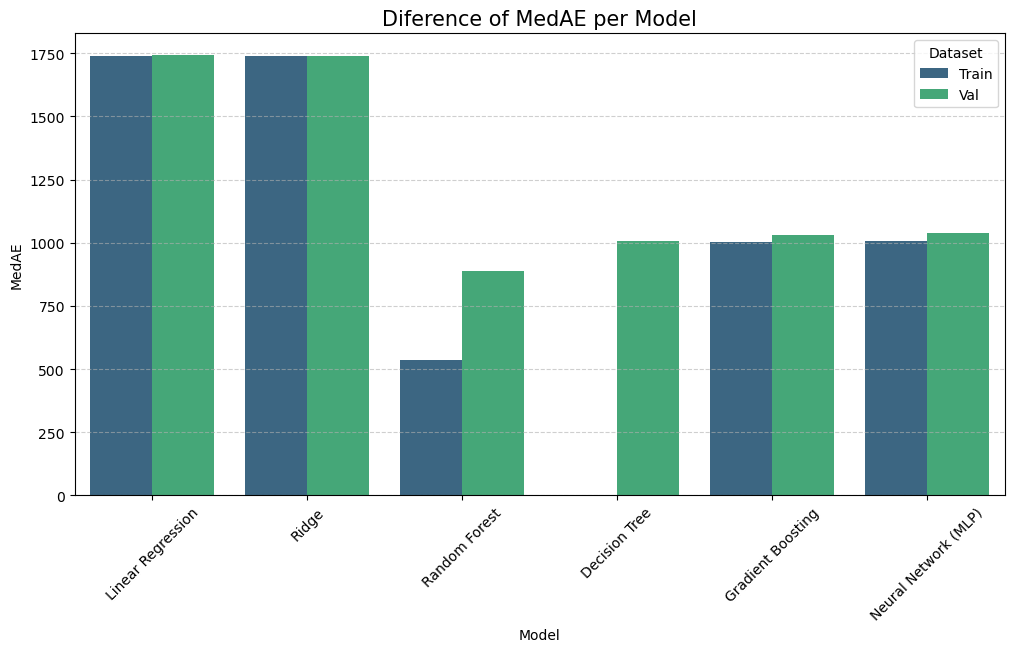

In [62]:
plot_comparison(full_results, metric_name='MedAE')

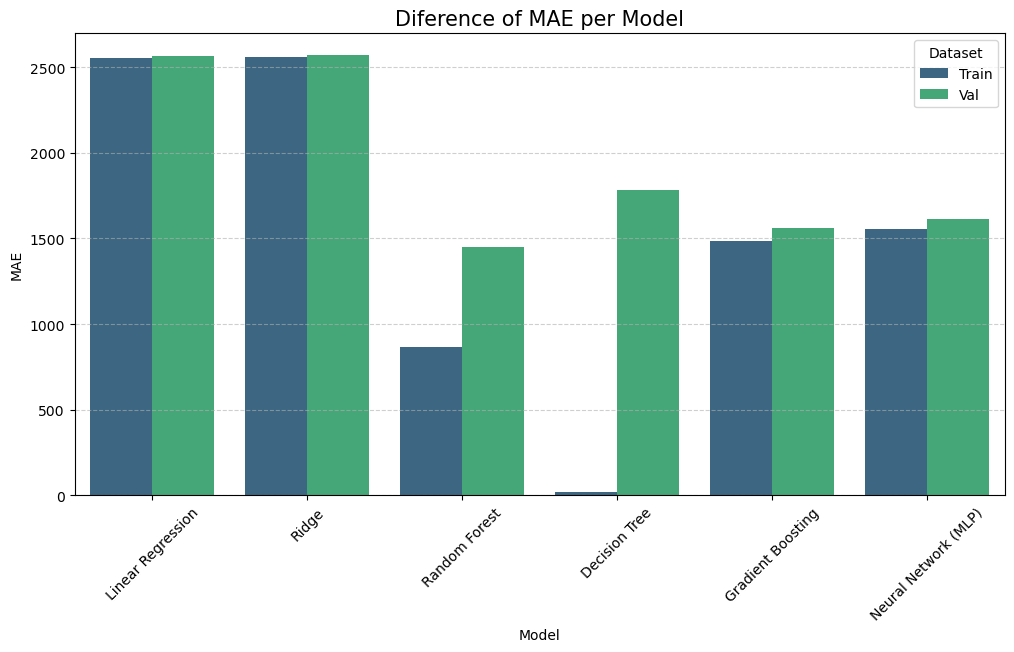

In [63]:
plot_comparison(full_results, metric_name='MAE')

From the *Metrics Results*, we were able to conclude a few things:
- **Linear Regression**: The difference between the datasets its very good, but the score itself could be better
- **Ridge**: Same as Linear Regression
- **Random Forest**: Even though it got the best results overall, we can see that the difference between training and validation is a bit high, which means that the model overfitted (a common thing for Tree based algorithms)
- **Decision Tree**: Complete overfit
- **Gradient Boosting**: It wasn't the model with the less diference between the datasets (train and val), but it has a low difference and a good score. Because of that, we will use GB as our main model going forward
- **MLP**: Similar to GB, it has a even lower difference between the datasets, but with worse results 

## Best Model Decider

Between the models and their results we had 3 solid options:
- Gradient Boosting
- Ensemble (GB with RF)
- Ensemble (GB with MLP)

To make our choice we took into consideration the difference between the datasets

## Hyperparameter tunning

In this section, we will tune both algorithms, trying to find the best combination of parameters possible. To do so, we will start with the Random Forest and then Gradient Boosting.

For both algorithms we will use GridSearch. We inicialize a dictionary for each algorithm and fill them with a range of parameters.

#### Random Forest

For Random Forest we have:
- **n_estimators**: Interval for the number of trees
- **max_depth**: Interval for the maximum depth that a tree can have (otherwise it overfits)
- **max_features**: Number of features when splitting
- **min_samples_split**: Minimum number of samples required to split a node
- **min_samples_leaf**: Minimum number of samples required to be at a leaf node
- **bootstrap**: Uses samples to build each tree

In [129]:
# RANDOM FOREST hyperparameter grid

rf_grid = {
    'model_name': ['Random Forest'],
    'model': [RandomForestRegressor(random_state=42, n_jobs=-1)],
    'params': {
        # n_estimators: Number of trees in our forest
        'n_estimators': [1000, 1500],

        # max_depth: Maximum depth of each tree in the forest
        'max_depth': [20, 30],

        # Max features to consider at each split: sqrt (less features) or 1.0 (all features)
        'max_features': ['sqrt', 1.0],

        # Leaf control: min_samples_split which is the minimum number of samples to split an internal node
        #               min_samples_leaf which is the minimum number of samples required to be at a leaf node
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],

        # Bootstrap: True = Uses random sampling
        'bootstrap': [True]
    }
}

grids_to_test = [rf_grid]
rf_grid_results = {}


In [ ]:
print("Starting Random Forest Manual Grid Search")

# Validation Loop | Same as in the start
fold = 1
for train_index, val_index in cv.split(X, y):
    print(f"Processing Fold {fold}/5...")
    
# 1- Data Split
    X_train_fold = X.iloc[train_index].copy()
    X_val_fold = X.iloc[val_index].copy()

    y_train_fold = y[train_index]
    y_val_fold = y[val_index]

    # Log Transform of our target
    y_train_log = np.log1p(y_train_fold)
# 2- Preprocessing
    # Seperation of the numeric columns
    numeric_cols = X_train_fold.select_dtypes(include=np.number).columns

    # Impute the null values
    imputer = SimpleImputer(strategy='median')
    imputer.fit(X_train_fold[numeric_cols])

    # Apply the transformation
    X_train_fold[numeric_cols] = imputer.transform(X_train_fold[numeric_cols])
    X_val_fold[numeric_cols] = imputer.transform(X_val_fold[numeric_cols])

    # Encoding
    categorical_cols = X_train_fold.select_dtypes(include=['object', 'bool']).columns

    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    encoder.fit(X_train_fold[categorical_cols])

    X_train_encoded = encoder.transform(X_train_fold[categorical_cols])
    X_val_encoded = encoder.transform(X_val_fold[categorical_cols])

    # Arrays concatenation to form the final datasets
    X_train_final = np.hstack([X_train_fold[numeric_cols].values, X_train_encoded])
    X_val_final = np.hstack([X_val_fold[numeric_cols].values, X_val_encoded])

    encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
    all_feature_names = list(numeric_cols) + list(encoded_feature_names)

# 3- Scaling
    scaler = MinMaxScaler()
    scaler.fit(X_train_final)

    X_train_scaled = scaler.transform(X_train_final)
    X_val_scaled = scaler.transform(X_val_final)

# 4- Feature Selection
    # Calls the consensus function passing the column names
    selected = consensus_features(X_train_scaled, y_train_log, all_feature_names)

    # Find the indexes of the selected columns
    sel_idx = [all_feature_names.index(f) for f in selected]

    # Final datasets
    X_train_final = X_train_scaled[:, sel_idx]
    X_val_final   = X_val_scaled[:, sel_idx]
    
    # 5- Manual hyperparameter grid search
    for entry in grids_to_test:
        
        base_model = entry['model'][0]
        base_name = entry['model_name'][0]

        param_grid = list(ParameterGrid(entry['params']))
        
        for params in param_grid:
            # Create a unique name for this combination
            combo_name = f"{base_name} | {str(params)}"
            
            # Initialize if new
            if combo_name not in rf_grid_results:
                rf_grid_results[combo_name] = {m: [] for m in metrics}
            
            # Clone and set parameters
            m = clone(base_model)
            m.set_params(**params)
            
            # Training with Log
            # The model learns to predict logarithms
            m.fit(X_train_final, y_train_log)
            
            # Predicting (Outputs in Log)
            pred_log = m.predict(X_val_final)
            
            # Converts back into original scale
            pred = np.expm1(pred_log)
            
            # Save Scores
            for m_name, func in metrics.items():
                score = func(y_val_fold, pred)
                rf_grid_results[combo_name][m_name].append(score)
    
    fold += 1

Starting Random Forest Manual Grid Search
--> A processar Fold 1/5...


c:\Users\User\anaconda3\envs\Fall2526\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


--> A processar Fold 2/5...


c:\Users\User\anaconda3\envs\Fall2526\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


--> A processar Fold 3/5...


c:\Users\User\anaconda3\envs\Fall2526\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


--> A processar Fold 4/5...


c:\Users\User\anaconda3\envs\Fall2526\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


--> A processar Fold 5/5...


c:\Users\User\anaconda3\envs\Fall2526\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [131]:
# Display the results
print("\nTuning Completed")
rf_results_df = pd.DataFrame(rf_grid_results).T
rf_final_metrics = rf_results_df.map(lambda x: np.mean(x))

print("\nConfiguration Perfomance (Based on MAE)")
display(rf_final_metrics.round(4).sort_values(by='MAE', ascending=True).head(5))


Tuning Completed

Configuration Perfomance (Based on MAE)


,R2,MAE,MSE,MAPE,MedAE
"Random Forest | {'bootstrap': True, 'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 1500}",0.9386,1351.4459,5.819984e+06,0.0829,824.3749
"Random Forest | {'bootstrap': True, 'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 1000}",0.9386,1351.6670,5.823651e+06,0.0829,825.0993
"Random Forest | {'bootstrap': True, 'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1500}",0.9389,1354.9070,5.793147e+06,0.0832,826.1440
"Random Forest | {'bootstrap': True, 'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}",0.9389,1355.2043,5.798245e+06,0.0832,826.9456
"Random Forest | {'bootstrap': True, 'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 1500}",0.9350,1378.3538,6.159268e+06,0.0845,839.6605


#### Gradient Boosting

For Gradient Boosting we have:
- **n_estimators**: The number of boosting stages to perform (Since its robust to overfit we used a large number)
- **learning_rate**: Shrinks the contribution of each tree by the values in the parameter
- **max_depth**: Limits the number of nodes in the tree
- **subsample**: Fraction of samples to be used for fitting the base learners
- **max_features**: Number of features to consider

In [61]:
# GRADIENT BOOSTING hyperparameter grid 

gb_grid = {
    'model_name': ['Gradient Boosting'],
    'model': [GradientBoostingRegressor(random_state=42)],
    'params': {
        # n_estimators: Number of trees in the process, higher values increase accuracy but also training time
        'n_estimators': [4000, 6000],

        # learning_rate: Step size shrinkage used in update to prevent overfitting, lower values require more trees
        'learning_rate': [0.01, 0.005],

        # max_depth: Maximum depth of each tree 
        'max_depth': [6, 7],

        # subsample being lower than 1.0 makes it use only a fraction of the data for each tree, 0.8 is common
        'subsample': [0.8],

        # max_features: Number of features to consider when looking for the best split: sqrt (less features) or 1.0 (all features)
        'max_features': ['sqrt', 1.0]
    }
}

grids_to_test = [gb_grid]
gb_grid_results = {}

In [62]:
print("Starting Gradient Boosting Manual Grid Search")

# Validation Loop | Same as in the start
fold = 1
for train_index, val_index in cv.split(X, y):
    print(f"Processing {fold}/5...")
    
# 1- Data Split
    X_train_fold = X.iloc[train_index].copy()
    X_val_fold = X.iloc[val_index].copy()
    y_train_fold = y[train_index]
    y_val_fold = y[val_index]

    y_train_log = np.log1p(y_train_fold)
# 2- Preprocessing
    # Separation of the numeric columns
    numeric_cols = X_train_fold.select_dtypes(include=np.number).columns

    # Impute the null values
    imputer = SimpleImputer(strategy='median')
    imputer.fit(X_train_fold[numeric_cols])

    # Apply the transformation
    X_train_fold[numeric_cols] = imputer.transform(X_train_fold[numeric_cols])
    X_val_fold[numeric_cols] = imputer.transform(X_val_fold[numeric_cols])

    # Encoding
    categorical_cols = X_train_fold.select_dtypes(include=['object', 'bool']).columns

    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    encoder.fit(X_train_fold[categorical_cols])

    X_train_encoded = encoder.transform(X_train_fold[categorical_cols])
    X_val_encoded = encoder.transform(X_val_fold[categorical_cols])

    # Arrays concatenation to form the final datasets
    X_train_final = np.hstack([X_train_fold[numeric_cols].values, X_train_encoded])
    X_val_final = np.hstack([X_val_fold[numeric_cols].values, X_val_encoded])

    encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
    all_feature_names = list(numeric_cols) + list(encoded_feature_names)

# 3- Scaling
    scaler = MinMaxScaler()
    scaler.fit(X_train_final)

    X_train_scaled = scaler.transform(X_train_final)
    X_val_scaled = scaler.transform(X_val_final)

# 4- Feature Selection
    # Calls the consensus function passing the column names
    selected = consensus_features(X_train_scaled, y_train_fold, all_feature_names)

    # Find the indexes of the selected columns
    sel_idx = [all_feature_names.index(f) for f in selected]

    # Final datasets
    X_train_final = X_train_scaled[:, sel_idx]
    X_val_final   = X_val_scaled[:, sel_idx]
    
    # 5- Manual hyperparameter grid search
    for entry in grids_to_test:

        base_model = entry['model'][0]
        base_name = entry['model_name'][0]
        
        param_grid = list(ParameterGrid(entry['params']))
        
        for params in param_grid:
            # Create a unique name for this combination
            combo_name = f"{base_name} | {str(params)}"
            
            # Initialize if new
            if combo_name not in gb_grid_results:
                gb_grid_results[combo_name] = {m: [] for m in metrics}
            
            # Clone and set parameters
            m = clone(base_model)
            m.set_params(**params)
            
            # Training with Log
            # The model learns to predict logarithms
            m.fit(X_train_final, y_train_log) 
            
            # Predicting (Outputs in Log)
            pred_log = m.predict(X_val_final)
            
            # [Converts back into original scale
            pred = np.expm1(pred_log)
            
            # Save Scores
            for m_name, func in metrics.items():
                score = func(y_val_fold, pred)
                gb_grid_results[combo_name][m_name].append(score)
    
    fold += 1


Starting Gradient Boosting Manual Grid Search
Processing 1/5...


c:\Users\rafad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


KeyboardInterrupt: 

In [134]:
# Display the results
print("\nTuning Completed")
gb_results_df = pd.DataFrame(gb_grid_results).T
gb_final_metrics = gb_results_df.map(lambda x: np.mean(x))

print("\nConfiguration Perfomance (Based on MAE)")
display(gb_final_metrics.round(4).sort_values(by='MAE', ascending=True).head(5))


Tuning Completed

Configuration Perfomance (Based on MAE)


,R2,MAE,MSE,MAPE,MedAE
"Gradient Boosting | {'learning_rate': 0.01, 'max_depth': 7, 'max_features': 1.0, 'n_estimators': 6000, 'subsample': 0.8}",0.9426,1343.4641,5.442511e+06,0.0810,840.7586
"Gradient Boosting | {'learning_rate': 0.01, 'max_depth': 7, 'max_features': 1.0, 'n_estimators': 4000, 'subsample': 0.8}",0.9397,1381.9159,5.713327e+06,0.0831,864.9477
"Gradient Boosting | {'learning_rate': 0.01, 'max_depth': 6, 'max_features': 1.0, 'n_estimators': 6000, 'subsample': 0.8}",0.9393,1392.7018,5.756526e+06,0.0836,872.8976
"Gradient Boosting | {'learning_rate': 0.005, 'max_depth': 7, 'max_features': 1.0, 'n_estimators': 6000, 'subsample': 0.8}",0.9370,1417.6231,5.972033e+06,0.0850,887.7169
"Gradient Boosting | {'learning_rate': 0.01, 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 6000, 'subsample': 0.8}",0.9360,1422.6488,6.065810e+06,0.0850,885.0623


## Best Model

In [100]:
final_model_randomforest = RandomForestRegressor(
    n_estimators=1500, 
    max_depth=10, 
    max_features='sqrt',  
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

In [63]:
final_model_gradientboosting = GradientBoostingRegressor(
    n_estimators=6000,
    learning_rate=0.01,
    max_depth=7,
    max_features=1.0,
    subsample=0.8,
    random_state=42
)

In [137]:
# Full deployment phase, we retrain on the full dataset and prepare the test set
# Load the original test set
X_test_kaggle = pd.read_csv('../new_datasets/X_test_preprocessed.csv')
X_full = X.copy()
y_full = y.copy()

# Separation of the numeric columns
numeric_cols = X_full.select_dtypes(include=np.number).columns

# Impute the null values
imputer = SimpleImputer(strategy='median')
imputer.fit(X_full[numeric_cols])

# Apply the transformation
X_full[numeric_cols] = imputer.transform(X_full[numeric_cols])
X_test_kaggle[numeric_cols] = imputer.transform(X_test_kaggle[numeric_cols])

# Encoding
categorical_cols = X_full.select_dtypes(include=['object', 'bool']).columns

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_full[categorical_cols])

X_full_encoded = encoder.transform(X_full[categorical_cols])
X_test_encoded = encoder.transform(X_test_kaggle[categorical_cols])

# Arrays concatenation to form the final datasets
X_full_processed = np.hstack([X_full[numeric_cols].values, X_full_encoded])
X_test_processed = np.hstack([X_test_kaggle[numeric_cols].values, X_test_encoded])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
all_feature_names = list(numeric_cols) + list(encoded_feature_names)

# Scaling
scaler = MinMaxScaler()
scaler.fit(X_full_processed)

X_full_scaled = scaler.transform(X_full_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Feature Selection
print("Feature Selection through Consensus on Full Data...")
y_full_log = np.log1p(y_full)

selected = consensus_features(X_full_scaled, y_full_log, all_feature_names)

# Find the indexes of the selected columns
sel_idx = [all_feature_names.index(f) for f in selected]

# Final datasets
X_full_final = X_full_scaled[:, sel_idx]
X_test_final = X_test_scaled[:, sel_idx]

print(f"Finished. Number of features selected: {X_full_final.shape[1]}")
print(f"Features selected: {selected}")

Feature Selection through Consensus on Full Data...
Finished. Number of features selected: 217
Features selected: ['Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes', 'Brand_Opel', 'Brand_Skoda', 'Brand_Toyota', 'Brand_Unknown', 'Brand_VW', 'age', 'age_mileage', 'engineSize', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'fuelType_Unknown', 'mileage', 'mileage_per_year', 'miles_mpg', 'model_2 Series', 'model_200', 'model_220', 'model_230', 'model_3 Series', 'model_4 Series', 'model_5 Series', 'model_6 Series', 'model_7 Series', 'model_8 Series', 'model_A Class', 'model_A1', 'model_A2', 'model_A3', 'model_A4', 'model_A5', 'model_A6', 'model_A7', 'model_A8', 'model_Adam', 'model_Agila', 'model_Amarok', 'model_Ampera', 'model_Antara', 'model_Arteon', 'model_Astra', 'model_Auris', 'model_Avensis', 'model_Aygo', 'model_B Class', 'model_B-MAX', 'model_Beetle', 'model_C Class', 'model_C-HR', 'model_C-MAX', 'model_CC', 'model_CL Class', 'model_CLA Class

In [64]:
# VALIDATION OF THE ENSEMBLE
# Using K-Fold to validate the ensemble approach on training data in relation to only Gradient Boosting

print("ENSEBLE VALIDATION: Gradient Boosting + Random Forest (70/30)")

# Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = []
r2_scores = []
gb_mae_scores = []
fold = 1

# Validation Loop
for train_index, val_index in kf.split(X, y):

# 1- Data Split
    X_train_fold, X_val_fold = X.iloc[train_index].copy(), X.iloc[val_index].copy()
    y_train_fold, y_val_fold = y[train_index], y[val_index]
    
    y_train_fold = np.log1p(y_train_fold)

# 2- Preprocessing
    # Separation of numeric columns
    numeric_cols = X_train_fold.select_dtypes(include=np.number).columns
    
    # Impute the null values
    imputer = SimpleImputer(strategy='median')
    imputer.fit(X_train_fold[numeric_cols])

    # Apply the transformation
    X_train_fold[numeric_cols] = imputer.transform(X_train_fold[numeric_cols])
    X_val_fold[numeric_cols] = imputer.transform(X_val_fold[numeric_cols])
    
    # Encoding
    categorical_cols = X_train_fold.select_dtypes(include=['object', 'bool']).columns

    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    encoder.fit(X_train_fold[categorical_cols])
    
    X_train_encoded = encoder.transform(X_train_fold[categorical_cols])
    X_val_encoded = encoder.transform(X_val_fold[categorical_cols])
    
    # Arrays concatenation to form the final datasets
    X_train_processed = np.hstack([X_train_fold[numeric_cols].values, X_train_encoded])
    X_val_processed = np.hstack([X_val_fold[numeric_cols].values, X_val_encoded])

#3- Scaling
    scaler = MinMaxScaler()
    scaler.fit(X_train_processed)

    X_train_scaled = scaler.transform(X_train_processed)
    X_val_scaled = scaler.transform(X_val_processed)
    
#4- Feature Selection
    # Calls the consensus function passing the column names
    selected = consensus_features(X_train_scaled, y_train_fold, all_feature_names)

    # Find the indexes of the selected columns
    sel_idx = [all_feature_names.index(f) for f in selected]

    # Final datasets
    X_train_final = X_train_scaled[:, sel_idx]
    X_val_final   = X_val_scaled[:, sel_idx]

    # Models Training
    # Gradient Boosting (Main Model)
    gb = GradientBoostingRegressor(n_estimators=6000, learning_rate=0.01, max_depth=7, 
                                   max_features=1.0, subsample=0.8, random_state=42)
    gb.fit(X_train_final, y_train_fold)
    
    # Random Forest (Secondary Model)
    #rf = RandomForestRegressor(n_estimators=1500, max_depth=30, max_features=1.0, 
     #                          min_samples_leaf=1, min_samples_split=2, n_jobs=-1, random_state=42)
    #rf.fit(X_train_final, y_train_fold)
    
    # Predictions
    pred_gb_log = gb.predict(X_val_final)
    #pred_rf_log = rf.predict(X_val_final)

    # Convert back to original scale
    pred_gb = np.expm1(pred_gb_log)
    #pred_rf = np.expm1(pred_rf_log)
    
    # Ensemble Prediction (70% GB + 30% RF)
    #pred_ensemble = (0.7 * pred_gb) + (0.3 * pred_rf)
    
    # Metrics Calculation
    mae = mean_absolute_error(y_val_fold, pred_gb)
    mae_gb = mean_absolute_error(y_val_fold, pred_gb)
    r2 = r2_score(y_val_fold, pred_gb)
    
    mae_scores.append(mae)
    gb_mae_scores.append(mae_gb)
    r2_scores.append(r2)
    
    print(f"Fold {fold}: MAE Ensemble = {mae:.2f} (Only Gradient Boosting Score: {mean_absolute_error(y_val_fold, pred_gb):.2f})")
    fold += 1

mean_ensemble_mae = np.mean(mae_scores)
mean_gb_mae = np.mean(gb_mae_scores)
# Final Results
print("\nFinal Ensemble Validation Results:")
print(f"Mean MAE: {np.mean(mae_scores):.4f}")
print(f"Mean R2:  {np.mean(r2_scores):.4f}")

if np.mean(mae_scores) < mean_gb_mae:
    print("Ensemble improves over only Gradient Boosting. Should be used in the final submission.")
else:
    print("Ensemble does not improve over only Gradient Boosting. Should only be used Gradient Boosting in the final submission.")

ENSEBLE VALIDATION: Gradient Boosting + Random Forest (70/30)


c:\Users\rafad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


KeyboardInterrupt: 

## Final Ensemble and Kaggle Submission

In [64]:
# Final deployment phase:

# Loading dataset
X_test_kaggle = pd.read_csv('../new_datasets/X_test_preprocessed.csv')
X_full = X.copy()
y_full = y.copy()

# Separation of the numeric columns
numeric_cols = X_full.select_dtypes(include=np.number).columns

# Impute the null values
imputer = SimpleImputer(strategy='median')
imputer.fit(X_full[numeric_cols])

# Apply the transformation
X_full[numeric_cols] = imputer.transform(X_full[numeric_cols])
X_test_kaggle[numeric_cols] = imputer.transform(X_test_kaggle[numeric_cols])

# Encoding
categorical_cols = X_full.select_dtypes(include=['object', 'bool']).columns

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_full[categorical_cols])

X_full_encoded = encoder.transform(X_full[categorical_cols])
X_test_encoded = encoder.transform(X_test_kaggle[categorical_cols])

# Arrays concatenation to form the final datasets
X_full_processed = np.hstack([X_full[numeric_cols].values, X_full_encoded])
X_test_processed = np.hstack([X_test_kaggle[numeric_cols].values, X_test_encoded])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
all_feature_names = list(numeric_cols) + list(encoded_feature_names)

# Scaling
scaler = MinMaxScaler()
scaler.fit(X_full_processed)

X_full_scaled = scaler.transform(X_full_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Feature Selection
print("Feature Selection through Consensus on Full Data...")
#y_full_log = np.log1p(y_full)

selected = consensus_features(X_full_scaled, y_full, all_feature_names)

# Find the indexes of the selected columns
sel_idx = [all_feature_names.index(f) for f in selected]

# Final datasets
X_full_final = X_full_scaled[:, sel_idx]
X_test_final = X_test_scaled[:, sel_idx]

print(f"Features selected: {selected}")

#Model Training on Full Data
print("\nTraining Final Models on Full Data...")


print("Random Forest (1500 Árvores)...")
rf_final = RandomForestRegressor(
    n_estimators=1500, 
    max_depth=10, 
    max_features=1.0, 
    min_samples_leaf=1, 
    min_samples_split=2, 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)
rf_final.fit(X_full_final, y_full)
'''
print("\nNN")
nn_final = MLPRegressor(
    hidden_layer_sizes=(100,50), max_iter=500, random_state=42, verbose=True
)
nn_final.fit(X_full_final, y_full)
'''
print("Gradient Boosting (6000 Árvores)...")
gb_final = GradientBoostingRegressor(
    n_estimators=6000,      
    learning_rate=0.01,     
    max_depth=7,            
    max_features=1.0,       
    subsample=0.8,          
    random_state=42,
    verbose=1
)
gb_final.fit(X_full_final, y_full)

# Generating the Final Ensemble Predictions
print("\nEnsemble Generation...")

# Predictions (Log scale)
pred_rf = rf_final.predict(X_test_final)
#pred_nn = nn_final.predict(X_test_final)
pred_gb = gb_final.predict(X_test_final)

# Convert back to original scale


# ENSEMBLE Prediction (70% GB + 30% RF)
pred_ensemble = (pred_gb * 0.7) + (pred_rf * 0.3)

# Saving the submission file
submission = pd.DataFrame({
    'CarID': pd.read_csv('../original_datasets/test.csv')['carID'],
    'price': pred_ensemble
})

filename = 'kaggle_submission.csv'
submission.to_csv(filename, index=False)

print(f"Finished! Submission file '{filename}' created successfully.")

Feature Selection through Consensus on Full Data...
Features selected: ['Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Opel', 'Brand_Skoda', 'Brand_Toyota', 'Brand_Unknown', 'Brand_VW', 'age', 'engineSize', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'fuelType_Unknown', 'mileage_per_year', 'model_2 Series', 'model_3 Series', 'model_4 Series', 'model_5 Series', 'model_7 Series', 'model_8 Series', 'model_A Class', 'model_A1', 'model_A3', 'model_A4', 'model_Adam', 'model_Astra', 'model_Auris', 'model_Aygo', 'model_B Class', 'model_B-MAX', 'model_C Class', 'model_C-MAX', 'model_CL Class', 'model_Caravelle', 'model_Citigo', 'model_Corsa', 'model_E Class', 'model_EcoSport', 'model_Edge', 'model_Fabia', 'model_Fiesta', 'model_G Class', 'model_GLA Class', 'model_GLC Class', 'model_GLE Class', 'model_GLS Class', 'model_Galaxy', 'model_Golf', 'model_Golf SV', 'model_Grandland X', 'model_IX20', 'model_Insignia', 'model_Ka', 'model_Karoq', 'model_Kodiaq', 'model_Land Cruiser', 'mod

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   22.2s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:   40.3s
[Parallel(n_jobs=-1)]: Done 1218 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1500 out of 1500 | elapsed:  1.4min finished


Gradient Boosting (6000 Árvores)...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1    93909736.3936     1562380.4799           59.37m
         2    90526597.1476    -5797125.6572           57.82m
         3    89944664.0385     5285272.0031           57.28m
         4    89488115.2507     5638628.0068           55.95m
         5    86733752.1899    -3713145.5331           55.62m
         6    86475369.3406     6179192.5832           55.18m
         7    85156271.8481     1776678.6230           54.90m
         8    83477304.8217      204539.2569           54.46m
         9    81694413.4211     -380122.3374           54.16m
        10    80846112.5739     3242576.4032           53.91m
        20    68963769.4416     2271171.4481           53.27m
        30    58411616.6421    -2426454.6593           52.99m
        40    49556293.7509    -1159141.0061           52.88m
        50    43628621.0253     -771254.0391           52.60m
        60    38001062.8842     -

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 1500 out of 1500 | elapsed:    1.7s finished


Finished! Submission file 'kaggle_submission.csv' created successfully.


## Deployment
The predictions for the test set have been exported to `kaggle_submission.csv` for validation against the unseen dataset.
Which got a MAE of 1294.17413